In [5]:
import numpy as np
from itertools import product
from dyn_modelling.models.cell_lattice import build_lattice, simulate_cell_lattice, compute_distance_matrix, compute_rhs, compute_weights, external_signal
from dyn_modelling.methods.SINDy import generate_sindy_dataset, build_library, build_extended_library, fit_sindy, print_model
from dyn_modelling.utils.plots import plot_graph, plot_trajectories
from dyn_modelling.utils.data import add_noise , sample_signal_params

## 1. Build the lattice


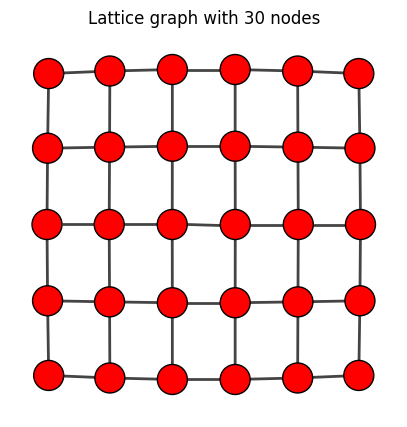

In [6]:
rows, cols = 5, 6
N = rows * cols
g = build_lattice(rows, cols)
plot_graph(g)


# Parameters
a_params = np.array([2.4, 3.5, 2.0, 1.0])
l_params = np.array([1.0, 1.0, 0.2])
t_on, t_off = 10.0, 100.0
t_end = 100.0
neigh_order = 2

delta_t = 0.25
t_eval = np.arange(0.0, t_end + delta_t/2, delta_t)
n_steps = len(t_eval)

# Build RHS
dist_matrix = compute_distance_matrix(g)
w = np.array(compute_weights(dist_matrix, neigh_order))
rhs = compute_rhs(g, dist_matrix, l_params, neigh_order, t_on, t_off, a_params=a_params)

# Initial conditions
np.random.seed(1)
x0 = np.random.rand(N * 3)
t_eval = np.linspace(0, t_end, n_steps)


In [7]:
n_traj = 20
rng = np.random.default_rng(0)
t_on_arr, t_off_arr = sample_signal_params(n_traj, (0.0, t_end), rng)

trajectories = []
for t_on_i, t_off_i in zip(t_on_arr, t_off_arr):
    rhs_i = compute_rhs(g, dist_matrix, l_params, neigh_order, t_on_i, t_off_i, a_params=a_params)
    x0_i = rng.uniform(0, 1, size=N * 3)
    y_i = simulate_cell_lattice(rhs_i, x0_i, (0, t_end), t_eval)
    trajectories.append({"y": y_i, "t": t_eval, "t_on": t_on_i, "t_off": t_off_i})


In [8]:
#Build the SINDy dataset
x_list, ctrl_list, t_list = generate_sindy_dataset(trajectories, w, external_signal)

#Fit the SINDy model
model_correct = fit_sindy(x_list, ctrl_list, t_list, build_library())
model_extended = fit_sindy(x_list, ctrl_list, t_list, build_extended_library())

print("correct library:")
print_model(model_correct)
print()
print("extended library:")
print_model(model_extended)



correct library:
u' = -0.926*u + 2.232*1/(1+v^2) + 0.918*Sext/(1+Phi^2)
v' = -0.981*v + 3.432*1/(1+u^2)
s' = -0.199*s + 0.398*u^2/(1+u^2)

extended library:
u' = -0.940*u + 0.551*1/(1+u^2) + 1.685*1/(1+v^2) + 0.584*u^2/(1+u^2) + -0.550*v^2/(1+v^2) + 0.915*Sext/(1+Phi^2)
v' = -0.990*v + 2.578*1/(1+u^2) + 0.837*1/(1+v^2) + -0.853*u^2/(1+u^2) + 0.888*v^2/(1+v^2)
s' = -0.200*s + -0.098*1/(1+u^2) + 0.103*1/(1+v^2) + 0.298*u^2/(1+u^2) + 0.097*v^2/(1+v^2)


In [9]:
feat_names = model_extended.feature_library.get_feature_names(["u", "v", "s", "Sext", "Phi"])
coeffs = model_extended.coefficients()

for row_name, row in zip(["u'", "v'", "s'"], coeffs):
    print(row_name)
    for c, n in zip(row, feat_names):
        print(f"  {n}: {c:.5f}")
    print()

u'
  u: -0.94008
  v: 0.00000
  s: 0.00000
  1/(1+u^2): 0.55073
  1/(1+v^2): 1.68499
  u^2/(1+u^2): 0.58411
  v^2/(1+v^2): -0.55015
  Sext: 0.00000
  Sext/(1+Phi^2): 0.91493
  1/(1+Phi^2): 0.00000
  u^2: 0.00000
  v^2: 0.00000
  s^2: 0.00000

v'
  u: 0.00000
  v: -0.98965
  s: 0.00000
  1/(1+u^2): 2.57797
  1/(1+v^2): 0.83697
  u^2/(1+u^2): -0.85284
  v^2/(1+v^2): 0.88815
  Sext: 0.00000
  Sext/(1+Phi^2): 0.00000
  1/(1+Phi^2): 0.00000
  u^2: 0.00000
  v^2: 0.00000
  s^2: 0.00000

s'
  u: 0.00000
  v: 0.00000
  s: -0.19960
  1/(1+u^2): -0.09774
  1/(1+v^2): 0.10311
  u^2/(1+u^2): 0.29832
  v^2/(1+v^2): 0.09747
  Sext: 0.00000
  Sext/(1+Phi^2): 0.00000
  1/(1+Phi^2): 0.00000
  u^2: 0.00000
  v^2: 0.00000
  s^2: 0.00000

